## Helix Fit Analysis

Lets try to do an Helix fit of the molecules, in order to see if the results improve and we can get perhaps better results that the cylproj approach.

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import time # For benchmarking

# Load data
u = md.Universe('md_1.tpr', 'md_1_noPBC.xtc')
u.trajectory[-1]
protein = u.select_atoms("protein")
xd, yd, zd = u.trajectory[-1].dimensions[0:3]/10

t_eq = 15000 # ps
# Time Data
ti = u.trajectory[0].time
tf = u.trajectory[-1].time
nt = len(u.trajectory)-1
deltat = (tf-ti)/nt
t = np.linspace(ti,tf,nt+1)
mask = (t >= t_eq)

### HELANAL Analysis - Adaptation

Ill try to adapt the idea of the helix fit that is presented in the HELANAL function of the MDAnlaysis module, perhaps instead based on the paper of [Sugeta and Miyazawa](https://onlinelibrary.wiley.com/doi/abs/10.1002/bip.1967.360050708). Its an old but rather simple approach.

They use the C-alpha atoms, so perhaps this should work for us instead of picking the "backbone" atoms (or might be the same).

In [7]:
mol = 0 
chains = protein.fragments[3*mol:3*mol + 3]
chain = chains[0].select_atoms("name CA")
coords_chain = chain.positions / 10

In [9]:
for i in range(3):
    print(f"Chain {i}", len(chains[i]))

Chain 0 2856
Chain 1 2918
Chain 2 2846


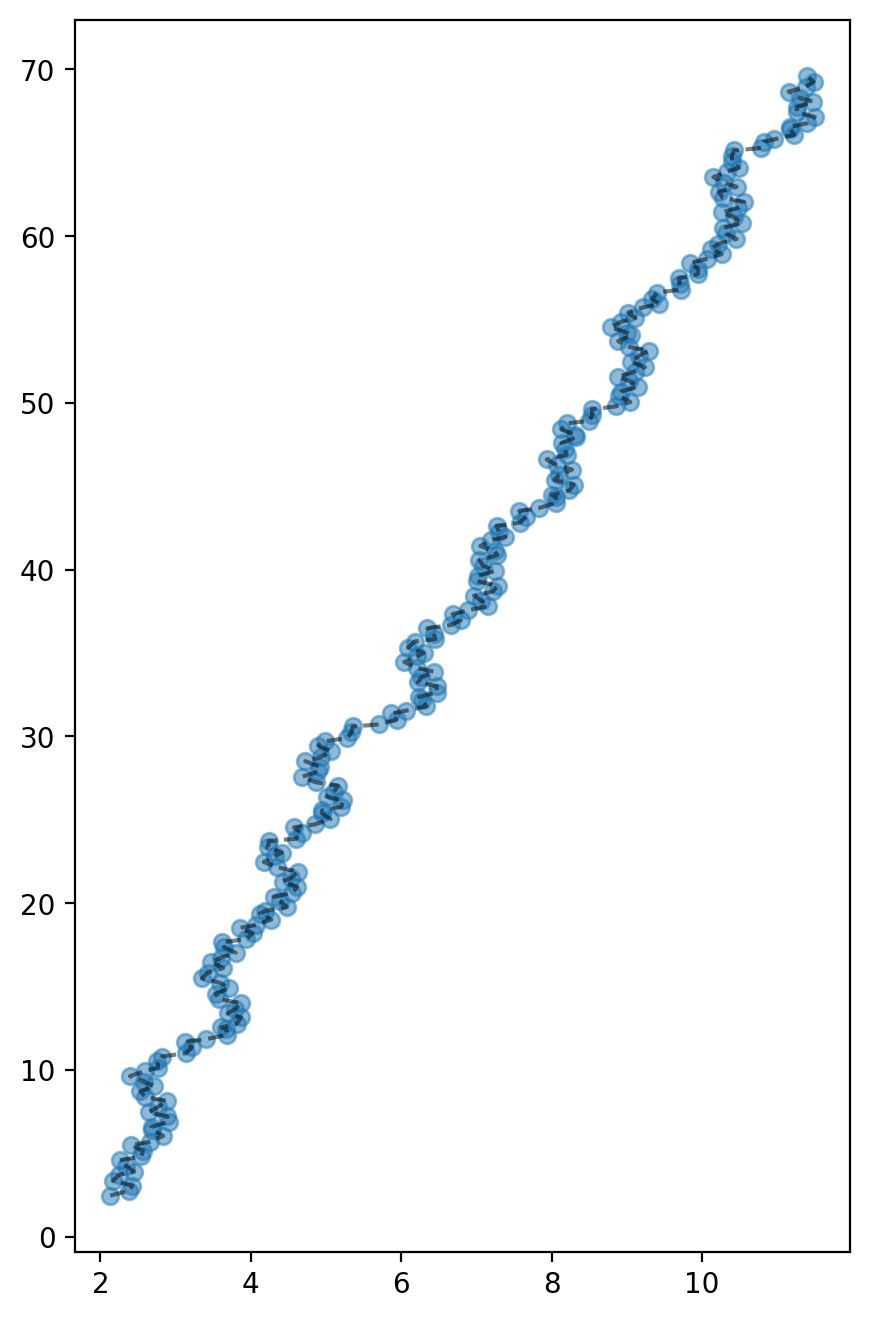

In [13]:
plt.figure(figsize=(5, 8),dpi=200)
plt.scatter(coords_chain[:, 0], coords_chain[:, 2], alpha=0.5)
plt.plot(coords_chain[:, 0], coords_chain[:, 2], alpha=0.5, linestyle='dashed', color='k')
plt.show()